# PINN Validation Against HYDRUS Ground Truth

This notebook validates PINN theta predictions against HYDRUS-1D numerical simulation results.

**HYDRUS Data:**
- Node 14 (20 cm depth)
- Node 30 (50 cm depth)  
- Node 50 (80 cm depth)

**Validation approach:**
1. Load HYDRUS observation data from `data/hydrus/Obs_node.out`
2. Load trained PINN model from checkpoint
3. Compute PINN theta predictions at same depths and times
4. Compare PINN vs HYDRUS with statistical metrics and plots

In [10]:
# Auto-reload modules
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Import PINN modules
from src.pinn_models import RichardsPINN
from src.normalization_helper import NormalizationHelper

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("✓ Modules loaded")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded


## 1. Load HYDRUS Observation Data

Load ground truth theta data from HYDRUS-1D simulation.

In [11]:
# Load HYDRUS data
hydrus_file = '../data/hydrus/Obs_node.out'

print("="*70)
print("LOADING HYDRUS OBSERVATION DATA")
print("="*70)

# Read the file, skipping header lines
# Data starts at line 12 (0-indexed: line 11)
with open(hydrus_file, 'r') as f:
    lines = f.readlines()

# Parse data (skip first 11 lines)
data_lines = lines[11:]

# Parse columns: time, h1, theta1, flux1, h2, theta2, flux2, h3, theta3, flux3
hydrus_data = []
for line in data_lines:
    if line.strip():
        values = line.split()
        if len(values) >= 10:  # Ensure we have all columns
            try:
                time_hours = float(values[0])
                # Node 14 (20 cm)
                h1 = float(values[1])
                theta1 = float(values[2])
                # Node 30 (50 cm)
                h2 = float(values[4])
                theta2 = float(values[5])
                # Node 50 (80 cm)
                h3 = float(values[7])
                theta3 = float(values[8])
                
                hydrus_data.append({
                    'time_hours': time_hours,
                    'time_seconds': time_hours * 3600,
                    'time_days': time_hours / 24,
                    'theta_20cm': theta1,
                    'theta_50cm': theta2,
                    'theta_80cm': theta3,
                    'h_20cm': h1,
                    'h_50cm': h2,
                    'h_80cm': h3,
                })
            except ValueError:
                continue

# Convert to DataFrame
df_hydrus = pd.DataFrame(hydrus_data)

print(f"\nLoaded {len(df_hydrus)} time steps from HYDRUS")
print(f"Time range: {df_hydrus['time_hours'].min():.2f} - {df_hydrus['time_hours'].max():.2f} hours")
print(f"           ({df_hydrus['time_days'].min():.2f} - {df_hydrus['time_days'].max():.2f} days)")
print(f"\nTheta ranges:")
print(f"  20 cm: {df_hydrus['theta_20cm'].min():.4f} - {df_hydrus['theta_20cm'].max():.4f}")
print(f"  50 cm: {df_hydrus['theta_50cm'].min():.4f} - {df_hydrus['theta_50cm'].max():.4f}")
print(f"  80 cm: {df_hydrus['theta_80cm'].min():.4f} - {df_hydrus['theta_80cm'].max():.4f}")

# Display first few rows
print("\nFirst 5 rows:")
print(df_hydrus.head())

print("="*70)

LOADING HYDRUS OBSERVATION DATA

Loaded 517 time steps from HYDRUS
Time range: 0.07 - 168.00 hours
           (0.00 - 7.00 days)

Theta ranges:
  20 cm: 0.1043 - 0.3430
  50 cm: 0.1614 - 0.3183
  80 cm: 0.2200 - 0.2954

First 5 rows:
   time_hours  time_seconds  time_days  theta_20cm  theta_50cm  theta_80cm  \
0      0.0740        266.40   0.003083      0.1043      0.1614      0.2239   
1      0.1000        360.00   0.004167      0.1043      0.1617      0.2241   
2      0.1312        472.32   0.005467      0.1043      0.1619      0.2244   
3      0.1722        619.92   0.007175      0.1044      0.1621      0.2249   
4      0.2268        816.48   0.009450      0.1044      0.1622      0.2255   

   h_20cm  h_50cm  h_80cm  
0  -18.78   -9.15   -5.07  
1  -18.77   -9.13   -5.06  
2  -18.76   -9.11   -5.04  
3  -18.76   -9.09   -5.02  
4  -18.75   -9.08   -4.99  


## 2. Load Trained PINN Model

Load the checkpoint and reconstruct the PINN model.

In [12]:
# Load checkpoint
checkpoint_path = '../checkpoints_train/checkpoint_final_czo.pt'

print("="*70)
print("LOADING TRAINED PINN MODEL")
print("="*70)
print(f"Checkpoint: {checkpoint_path}\n")

checkpoint = torch.load(checkpoint_path, map_location=device)

# Extract parameters from checkpoint
norm_params = checkpoint['normalization_params']
soil_params = norm_params['soil_params']
L = norm_params['L']
S_max = norm_params['S_max']
Sy = norm_params['Sy']
zr = norm_params['zr']

network_scaling = checkpoint['network_scaling']
t_ref_tilde = network_scaling['t_ref_tilde']
z_max_tilde = network_scaling['z_max_tilde']

# Infer network architecture from state_dict
state_dict = checkpoint['model_state_dict']

# Count h_net layers and get hidden_dim
h_net_layers = [k for k in state_dict.keys() if k.startswith('h_net.net.') and k.endswith('.weight')]
h_net_hidden_dim = state_dict['h_net.net.0.weight'].shape[0]  # Output dim of first layer
# num_layers = (total_linear_layers - 1) because output layer doesn't count
h_net_num_layers = len(h_net_layers) - 1

# Count zb_net layers and get hidden_dim
zb_net_layers = [k for k in state_dict.keys() if k.startswith('zb_net.net.') and k.endswith('.weight')]
zb_net_hidden_dim = state_dict['zb_net.net.0.weight'].shape[0]
zb_net_num_layers = len(zb_net_layers) - 1

h_net_config = {'hidden_dim': h_net_hidden_dim, 'num_layers': h_net_num_layers}
zb_net_config = {'hidden_dim': zb_net_hidden_dim, 'num_layers': zb_net_num_layers}

print(f"Model configuration:")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Soil params: {soil_params}")
print(f"  L: {L}, S_max: {S_max}")
print(f"  Sy: {Sy}, zr: {zr}")
print(f"  h_net: {h_net_config}")
print(f"  zb_net: {zb_net_config}")

# Create normalizer first (required before model initialization)
normalizer = NormalizationHelper(soil_params, L=L, S_max=S_max)
print(f"\n✓ Normalizer created")
print(f"  T (time scale): {normalizer.T:.2f} s")
print(f"  L (length scale): {normalizer.L:.2f} m")

# Reconstruct model
# Note: We need theta0_data for initialization, but we'll use dummy data since we're only doing inference
dummy_theta0_data = (np.array([0.0, 1.0]), np.array([0.2, 0.2]))

model = RichardsPINN(
    soil_params=soil_params,
    theta0_data=dummy_theta0_data,
    Sy=Sy,
    zr=zr,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    normalizer=normalizer,  # Pass the normalizer we created
    zb_initial=1.5,  # Default, will be overwritten by state_dict
    t_max=86400,  # Default
    z_max_tilde=z_max_tilde,
    t_ref_days=15.0,  # Default
    ic_profile=None,
    ic_type='obs',
    device=device
)

# Load model state
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
model.to(device)

print(f"\n✓ Model loaded successfully")
print("="*70)

LOADING TRAINED PINN MODEL
Checkpoint: ../checkpoints_train/checkpoint_final_czo.pt

Model configuration:
  Epoch: 999999
  Soil params: {'theta_s': 0.4, 'theta_r': 0.01, 'alpha': 0.4, 'n': 1.7, 'Ks': 1e-05, 'l': 0.5}
  L: 4.0, S_max: 1e-07
  Sy: 0.3, zr: 0.5
  h_net: {'hidden_dim': 64, 'num_layers': 4}
  zb_net: {'hidden_dim': 32, 'num_layers': 3}

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.390
Time scale (T):             1.56e+05 s (43.33 hours)
Dimensionless α̃:            1.6000
Dimensionless S̃_max:        0.0400


✓ Normalizer created
  T (time scale): 156000.00 s
  L (length scale): 4.00 m

✓ Model loaded successfully


## 3. Compute PINN Theta Predictions

Evaluate PINN at the same depths and times as HYDRUS data.

In [13]:
print("="*70)
print("COMPUTING PINN THETA PREDICTIONS")
print("="*70)

# Define depths (negative because z=0 is surface, z<0 is underground)
depths_cm = [20, 50, 80]
depths_m = [-d / 100.0 for d in depths_cm]  # Convert to meters and make negative

print(f"Depths: {depths_cm} cm = {depths_m} m")
print(f"Time steps: {len(df_hydrus)}")

# Prepare input tensors
times_seconds = df_hydrus['time_seconds'].values

# Storage for PINN predictions
pinn_predictions = {}

with torch.no_grad():
    for depth_cm, depth_m in zip(depths_cm, depths_m):
        print(f"\nProcessing depth {depth_cm} cm ({depth_m:.2f} m)...")
        
        # Create tensors for this depth (need 2D tensors with shape [N, 1])
        z_tensor = torch.full((len(times_seconds), 1), depth_m, dtype=torch.float32, device=device)
        t_tensor = torch.tensor(times_seconds, dtype=torch.float32, device=device).reshape(-1, 1)
        
        # Predict pressure head
        h_pinn, _ = model.predict_head(z_tensor, t_tensor)
        
        # Convert h → Se using van Genuchten (normalized space)
        h_tilde = model.normalizer.normalize_h(h_pinn)
        Se_pinn = model.normalizer.Se_tilde(h_tilde)
        
        # Convert Se → theta: θ = θr + Se × (θs - θr)
        theta_pinn = (soil_params['theta_r'] + 
                     Se_pinn.cpu().numpy().flatten() * 
                     (soil_params['theta_s'] - soil_params['theta_r']))
        
        # Store predictions
        pinn_predictions[f'theta_{depth_cm}cm'] = theta_pinn
        pinn_predictions[f'h_{depth_cm}cm'] = h_pinn.cpu().numpy().flatten()
        
        print(f"  Theta range: {theta_pinn.min():.4f} - {theta_pinn.max():.4f}")
        print(f"  h range: {h_pinn.min().item():.4f} - {h_pinn.max().item():.4f} m")

# Add PINN predictions to dataframe
for key, values in pinn_predictions.items():
    df_hydrus[f'pinn_{key}'] = values

print("\n✓ PINN predictions computed")
print("="*70)

COMPUTING PINN THETA PREDICTIONS
Depths: [20, 50, 80] cm = [-0.2, -0.5, -0.8] m
Time steps: 517

Processing depth 20 cm (-0.20 m)...
  Theta range: 0.1289 - 0.3485
  h range: -13.1822 - -1.4811 m

Processing depth 50 cm (-0.50 m)...
  Theta range: 0.1801 - 0.3217
  h range: -7.5189 - -2.0674 m

Processing depth 80 cm (-0.80 m)...
  Theta range: 0.2046 - 0.3000
  h range: -5.9835 - -2.5766 m

✓ PINN predictions computed


## 4. Statistical Comparison

Calculate error metrics: RMSE, MAE, R², and relative error.

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("="*70)
print("STATISTICAL COMPARISON: PINN vs HYDRUS")
print("="*70)

# Calculate metrics for each depth
metrics_summary = []

for depth_cm in depths_cm:
    hydrus_col = f'theta_{depth_cm}cm'
    pinn_col = f'pinn_theta_{depth_cm}cm'
    
    hydrus_vals = df_hydrus[hydrus_col].values
    pinn_vals = df_hydrus[pinn_col].values
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(hydrus_vals, pinn_vals))
    mae = mean_absolute_error(hydrus_vals, pinn_vals)
    r2 = r2_score(hydrus_vals, pinn_vals)
    
    # Relative error (percentage)
    mean_hydrus = np.mean(hydrus_vals)
    relative_rmse = (rmse / mean_hydrus) * 100
    
    # Bias (mean error)
    bias = np.mean(pinn_vals - hydrus_vals)
    
    metrics_summary.append({
        'Depth (cm)': depth_cm,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Relative RMSE (%)': relative_rmse,
        'Bias': bias,
        'Mean HYDRUS': mean_hydrus,
        'Mean PINN': np.mean(pinn_vals)
    })
    
    print(f"\n{depth_cm} cm depth:")
    print(f"  RMSE:           {rmse:.6f} m³/m³")
    print(f"  MAE:            {mae:.6f} m³/m³")
    print(f"  R²:             {r2:.6f}")
    print(f"  Relative RMSE:  {relative_rmse:.2f}%")
    print(f"  Bias:           {bias:.6f} m³/m³")
    print(f"  Mean HYDRUS:    {mean_hydrus:.4f} m³/m³")
    print(f"  Mean PINN:      {np.mean(pinn_vals):.4f} m³/m³")

# Create summary table
df_metrics = pd.DataFrame(metrics_summary)

print("\n" + "="*70)
print("METRICS SUMMARY TABLE")
print("="*70)
print(df_metrics.to_string(index=False))
print("="*70)

STATISTICAL COMPARISON: PINN vs HYDRUS

20 cm depth:
  RMSE:           0.016071 m³/m³
  MAE:            0.012552 m³/m³
  R²:             0.936590
  Relative RMSE:  7.48%
  Bias:           -0.007489 m³/m³
  Mean HYDRUS:    0.2148 m³/m³
  Mean PINN:      0.2073 m³/m³

50 cm depth:
  RMSE:           0.012584 m³/m³
  MAE:            0.010082 m³/m³
  R²:             0.899604
  Relative RMSE:  5.56%
  Bias:           -0.005772 m³/m³
  Mean HYDRUS:    0.2262 m³/m³
  Mean PINN:      0.2204 m³/m³

80 cm depth:
  RMSE:           0.013341 m³/m³
  MAE:            0.010896 m³/m³
  R²:             0.704499
  Relative RMSE:  5.50%
  Bias:           -0.007239 m³/m³
  Mean HYDRUS:    0.2424 m³/m³
  Mean PINN:      0.2352 m³/m³

METRICS SUMMARY TABLE
 Depth (cm)     RMSE      MAE       R²  Relative RMSE (%)      Bias  Mean HYDRUS  Mean PINN
         20 0.016071 0.012552 0.936590           7.482712 -0.007489     0.214779   0.207289
         50 0.012584 0.010082 0.899604           5.563990 -0.005772     0

## 5. Visualization: Time Series & Scatter Plots

Combined view showing time series and scatter plots for each depth.

VISUALIZATION: TIME SERIES & SCATTER PLOTS


/var/folders/ml/rzck8tbd3wlfxlcx23nf59zm0000gn/T/ipykernel_12135/2145252210.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_sc.legend(loc='best', fontsize=10)


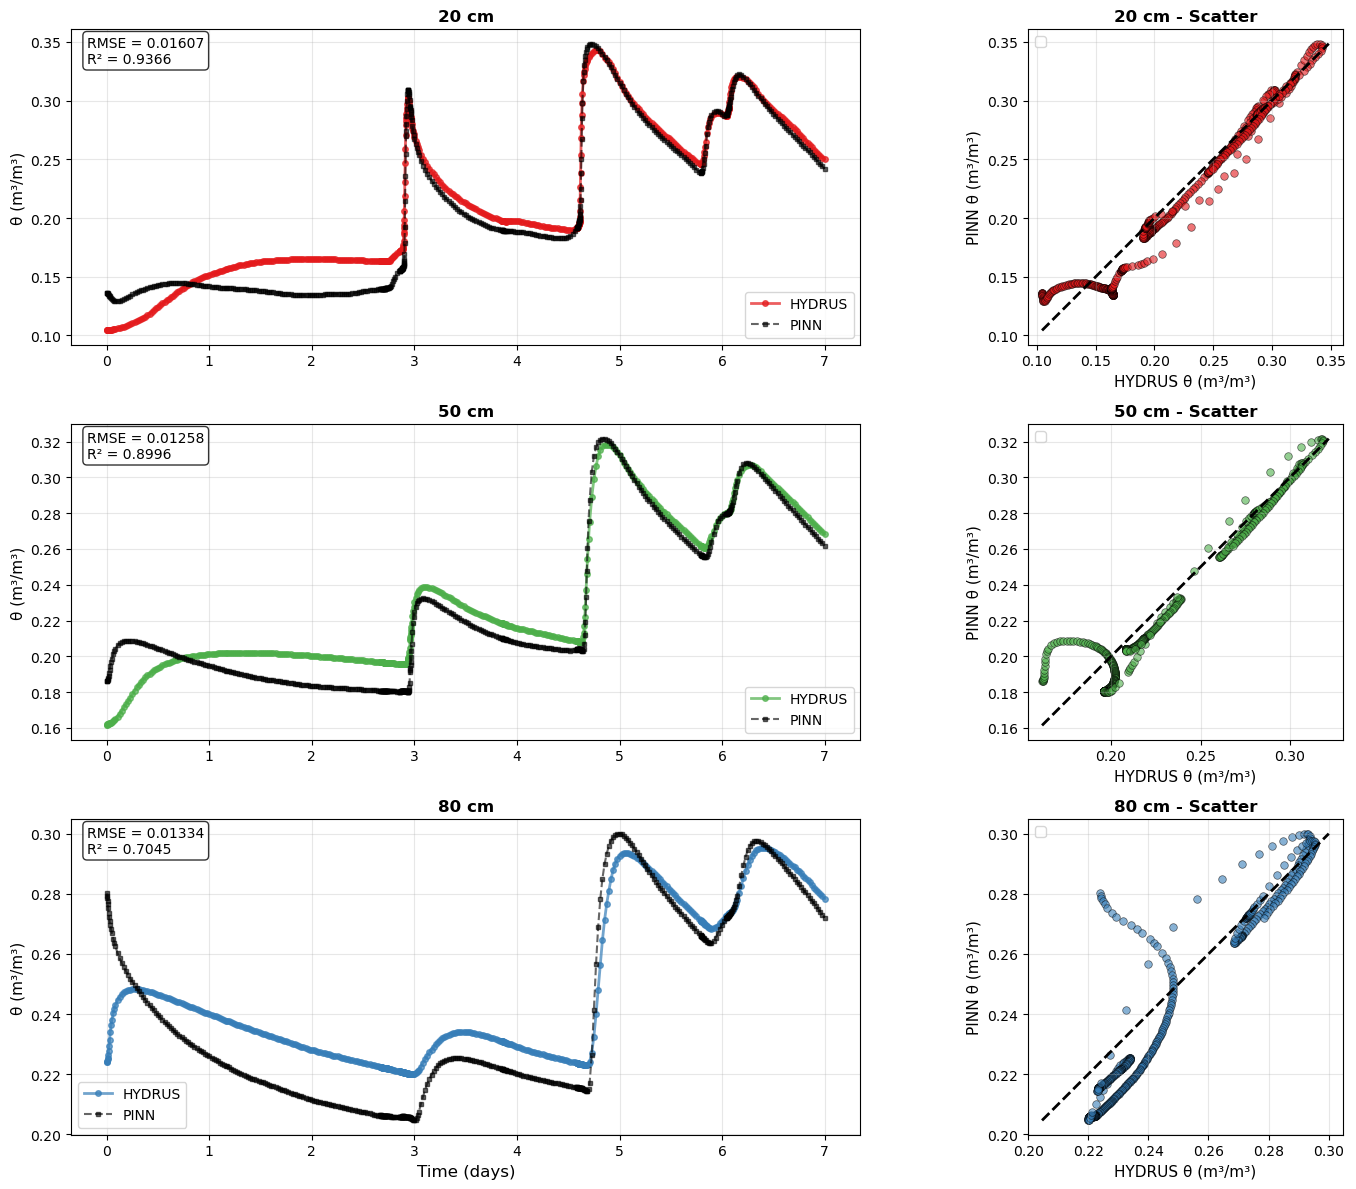

✓ Visualization generated


In [15]:
print("="*70)
print("VISUALIZATION: TIME SERIES & SCATTER PLOTS")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

colors = ['#e41a1c', '#4daf4a', '#377eb8']
depth_labels = ['20 cm', '50 cm', '80 cm']

for i, (depth_cm, color, label) in enumerate(zip(depths_cm, colors, depth_labels)):
    hydrus_col = f'theta_{depth_cm}cm'
    pinn_col = f'pinn_theta_{depth_cm}cm'
    
    t_days = df_hydrus['time_days'].values
    hydrus_vals = df_hydrus[hydrus_col].values
    pinn_vals = df_hydrus[pinn_col].values
    
    # Get metrics for this depth
    rmse = df_metrics[df_metrics['Depth (cm)'] == depth_cm]['RMSE'].values[0]
    r2 = df_metrics[df_metrics['Depth (cm)'] == depth_cm]['R²'].values[0]
    
    # LEFT: Time series plot
    ax_ts = axes[i, 0]
    ax_ts.plot(t_days, hydrus_vals, 'o-', color=color, 
               linewidth=2, markersize=4, alpha=0.7, label='HYDRUS')
    ax_ts.plot(t_days, pinn_vals, 's--', color='black',
               linewidth=1.5, markersize=3, alpha=0.6, label='PINN')
    
    ax_ts.set_ylabel('θ (m³/m³)', fontsize=11)
    ax_ts.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax_ts.legend(loc='best', fontsize=10)
    ax_ts.grid(True, alpha=0.3)
    
    # Add metrics box
    ax_ts.text(0.02, 0.98, f'RMSE = {rmse:.5f}\nR² = {r2:.4f}',
               transform=ax_ts.transAxes, fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # RIGHT: Scatter plot
    ax_sc = axes[i, 1]
    ax_sc.scatter(hydrus_vals, pinn_vals, c=color, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    
    # 1:1 line
    min_val = min(hydrus_vals.min(), pinn_vals.min())
    max_val = max(hydrus_vals.max(), pinn_vals.max())
    ax_sc.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
    
    ax_sc.set_xlabel('HYDRUS θ (m³/m³)', fontsize=11)
    ax_sc.set_ylabel('PINN θ (m³/m³)', fontsize=11)
    ax_sc.set_title(f'{label} - Scatter', fontsize=12, fontweight='bold')
    ax_sc.legend(loc='best', fontsize=10)
    ax_sc.grid(True, alpha=0.3)
    ax_sc.set_aspect('equal', adjustable='box')

# Only add x-label to bottom time series plot
axes[-1, 0].set_xlabel('Time (days)', fontsize=12)

plt.tight_layout()
plt.show()

print("✓ Visualization generated")
print("="*70)

## 6. Visualization: Error Distribution

Histograms showing the distribution of prediction errors at each depth.

VISUALIZATION: ERROR DISTRIBUTION


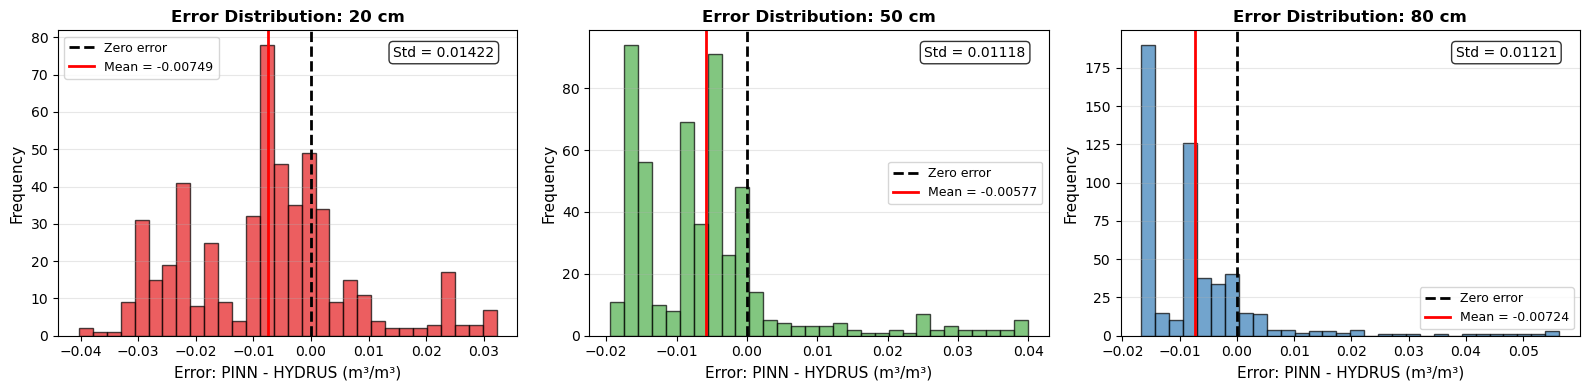

✓ Error distributions generated


In [16]:
print("="*70)
print("VISUALIZATION: ERROR DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = ['#e41a1c', '#4daf4a', '#377eb8']
depth_labels = ['20 cm', '50 cm', '80 cm']

for i, (depth_cm, ax, color, label) in enumerate(zip(depths_cm, axes, colors, depth_labels)):
    hydrus_col = f'theta_{depth_cm}cm'
    pinn_col = f'pinn_theta_{depth_cm}cm'
    
    errors = df_hydrus[pinn_col].values - df_hydrus[hydrus_col].values
    
    # Histogram
    ax.hist(errors, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero error')
    ax.axvline(errors.mean(), color='red', linestyle='-', linewidth=2, 
               label=f'Mean = {errors.mean():.5f}')
    
    ax.set_xlabel('Error: PINN - HYDRUS (m³/m³)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Error Distribution: {label}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add std to plot
    std = errors.std()
    ax.text(0.95, 0.95, f'Std = {std:.5f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("✓ Error distributions generated")
print("="*70)

## 7. Summary and Interpretation

Overall assessment of PINN performance against HYDRUS.

In [17]:
print("="*70)
print("VALIDATION SUMMARY")
print("="*70)

# Overall statistics
overall_rmse = df_metrics['RMSE'].mean()
overall_mae = df_metrics['MAE'].mean()
overall_r2 = df_metrics['R²'].mean()
overall_rel_rmse = df_metrics['Relative RMSE (%)'].mean()

print(f"\nOverall Performance (averaged across all depths):")
print(f"  Average RMSE:           {overall_rmse:.6f} m³/m³")
print(f"  Average MAE:            {overall_mae:.6f} m³/m³")
print(f"  Average R²:             {overall_r2:.6f}")
print(f"  Average Relative RMSE:  {overall_rel_rmse:.2f}%")

print(f"\nInterpretation:")
if overall_r2 > 0.9:
    print("  ✓ Excellent agreement (R² > 0.9)")
elif overall_r2 > 0.8:
    print("  ✓ Good agreement (R² > 0.8)")
elif overall_r2 > 0.7:
    print("  • Fair agreement (R² > 0.7)")
else:
    print("  ✗ Poor agreement (R² < 0.7) - model may need improvement")

if overall_rel_rmse < 5:
    print(f"  ✓ Very low relative error ({overall_rel_rmse:.2f}% < 5%)")
elif overall_rel_rmse < 10:
    print(f"  ✓ Low relative error ({overall_rel_rmse:.2f}% < 10%)")
elif overall_rel_rmse < 15:
    print(f"  • Moderate relative error ({overall_rel_rmse:.2f}% < 15%)")
else:
    print(f"  ✗ High relative error ({overall_rel_rmse:.2f}% > 15%)")

# Depth-specific performance
print(f"\nDepth-specific performance:")
best_depth = df_metrics.loc[df_metrics['R²'].idxmax(), 'Depth (cm)']
worst_depth = df_metrics.loc[df_metrics['R²'].idxmin(), 'Depth (cm)']
print(f"  Best prediction:  {best_depth} cm (R² = {df_metrics[df_metrics['Depth (cm)'] == best_depth]['R²'].values[0]:.4f})")
print(f"  Worst prediction: {worst_depth} cm (R² = {df_metrics[df_metrics['Depth (cm)'] == worst_depth]['R²'].values[0]:.4f})")

print("\n" + "="*70)
print("VALIDATION COMPLETE")
print("="*70)

VALIDATION SUMMARY

Overall Performance (averaged across all depths):
  Average RMSE:           0.013999 m³/m³
  Average MAE:            0.011176 m³/m³
  Average R²:             0.846897
  Average Relative RMSE:  6.18%

Interpretation:
  ✓ Good agreement (R² > 0.8)
  ✓ Low relative error (6.18% < 10%)

Depth-specific performance:
  Best prediction:  20 cm (R² = 0.9366)
  Worst prediction: 80 cm (R² = 0.7045)

VALIDATION COMPLETE
